In [1]:
import sys
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

sys.path.append("scripts/utils")
from plot_utils import hist_to_curve

sys.path.append("scripts/experimental/")
from data_class import SegmentationData

In [2]:
# Define normalised distributions
def gamma_distribution(x, a, scale):
    gamma = sc.stats.gamma.pdf(x, a, scale=scale)
    return gamma / np.sum(gamma)

def lognorm_distribution(x, a, scale):
    lognorm = sc.stats.lognorm.pdf(x, a, scale=scale)
    return lognorm / np.sum(lognorm)

In [3]:
# Set parameters
cell_density = 1900     # cells/mm²
Vmin = 500              # µm³
Vmax = 5000             # µm³

density_binsize = 200   # cells/mm²

In [4]:
# LOAD EXPERIMENTAL DATA

masks = []
cellprops = []
for dataset in ["holomonitor_20240319_A1-13",
                "holomonitor_20240301_B1-4"]:
                #"holomonitor_20240319_B1-11",
                #"holomonitor_20240319_A1-9",
                #"holomonitor_20240319_A1-13"]:

    cellprop = SegmentationData()
    cellprop.load(f"../../../../hdd_data/silja/VertexModel_data/experimental/processed/{dataset}/cell_props.p")
    cellprop.add_density()

    mask = (cellprop.density > cell_density - density_binsize / 2) * (cellprop.density < cell_density + density_binsize / 2)

    masks.append(mask)
    cellprops.append(cellprop)


State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240319_A1-13/cell_props.p.
State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240301_B1-4/cell_props.p.


In [5]:
# Compute experimental volumes
tmp_dist = []
for cellprop, mask in zip(cellprops, masks):
    tmp_dist.append((cellprop.A[mask] * cellprop.h[mask]).ravel())

tmp_dist = np.ma.concatenate(tmp_dist)

# Extract distribution
V_exp, freq_exp, _ = hist_to_curve(tmp_dist, 36, hist_range=[Vmin, Vmax])

# Normalise experimental distribution
freq_exp = freq_exp / np.sum(freq_exp)

In [6]:
# Fit lognormal distribution to experimental data
params, popt = curve_fit(lognorm_distribution, V_exp, freq_exp, p0=[1, np.mean(tmp_dist)])
lognorm      = lognorm_distribution(V_exp, *params)

print(f"Shape parameter: {params[0]:0.2f} +/- {popt[0,0]:0.2f}")
print(f"Scale parameter: {params[1]:0.0f} +/- {popt[1,1]:0.0f}")

Shape parameter: 0.30 +/- 0.00
Scale parameter: 2234 +/- 126


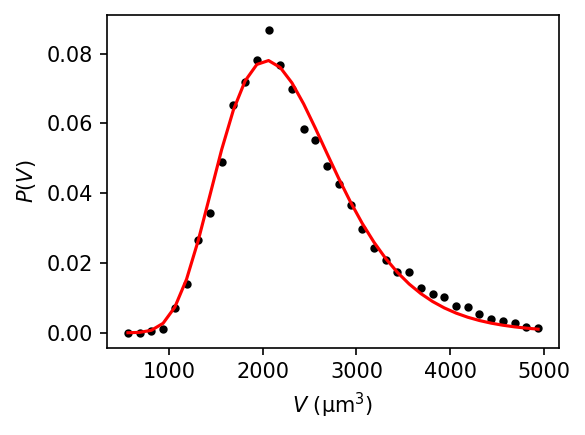

In [7]:
# Plot distributions
plt.figure(figsize=(4,3), dpi=150)

plt.plot(V_exp, freq_exp, 'k.')
plt.plot(V_exp, lognorm,  'r')

plt.xlabel(r"$V$ (µm$^3$)")
plt.ylabel(r"$P(V)$")
plt.tight_layout()